Es un excelente proyecto. Combinar imágenes satelitales (Sentinel) con Deep Learning para agricultura de precisión (silo bolsas) es un caso de uso muy potente, pero tiene sus trucos, especialmente en el manejo de coordenadas geoespaciales vs. coordenadas de píxeles.

Dado que no tienes GPU y quieres resultados en aprox. 2.5 horas, mi recomendación estratégica es:

Modelo: Usar Faster R-CNN con backbone ResNet-50. Es el estándar de oro para detección de objetos, es robusto y maneja bien objetos pequeños (los silo bolsas vistos desde satélite son rectángulos finos).

Datos: Aunque tengas 4 años de imágenes, para entrenar en CPU en 2 horas, no puedes usar todo. Seleccionaremos un subconjunto aleatorio (ej. 50-100 imágenes) para esta prueba de concepto.

Bandas: Los modelos pre-entrenados esperan 3 canales (RGB). Tus imágenes tienen 4 (RGB + NIR). Para esta primera prueba, usaremos solo RGB para aprovechar los pesos pre-entrenados sin modificar la arquitectura de la red (lo cual lo haría más lento y complejo).

Aquí tienes el plan de acción en dos pasos (Scripts):

Paso 1: Script para Organizar y Emparejar Datos (Data Split)
Este script buscará tus pares .tif y .shp, verificará que existan ambos, y moverá una muestra limitada a carpetas de entrenamiento/validación para que tu prueba sea rápida.

Nota: Necesitarás instalar geopandas y shapely (pip install geopandas shapely rasterio).

In [ ]:
import os
import shutil
import random
import geopandas as gpd
from tqdm import tqdm

def preparar_dataset_final(img_dir, shp_dir, output_dir, sample_size=80, seed=42):
    
    # FIJAR LA SEMILLA PARA REPRODUCIBILIDAD
    print(f"Configurando semilla aleatoria: {seed}")
    random.seed(seed)
    
    # 1. Verificar directorios
    if not os.path.exists(img_dir):
        print(f"ERROR: No existe la carpeta de imágenes: {img_dir}")
        return
    if not os.path.exists(shp_dir):
        print(f"ERROR: No existe la carpeta de shapes: {shp_dir}")
        return

    # 2. Listar archivos
    print(f"Leyendo imágenes desde: {img_dir}")
    tif_files = [f for f in os.listdir(img_dir) if f.lower().endswith('.tif')]
    
    print(f"Leyendo shapes desde: {shp_dir}")
    all_shp_files = os.listdir(shp_dir)
    shp_candidates = [f for f in all_shp_files if f.lower().endswith('.shp')]

    print(f"-> Imágenes encontradas: {len(tif_files)}")
    print(f"-> Shapes candidatos: {len(shp_candidates)}")

    valid_pairs = []

    # 3. Emparejamiento (Matching)
    print("Buscando parejas (Imagen <-> Shape)...")
    
    # Ordenamos las listas antes de procesar para garantizar que el orden de lectura 
    # sea siempre el mismo en cualquier sistema operativo (Windows/Linux)
    tif_files.sort()
    
    for tif in tqdm(tif_files):
        base_name = os.path.splitext(tif)[0]
        
        match = None
        for shp in shp_candidates:
            if shp.startswith(base_name):
                match = shp
                break
        
        if match:
            valid_pairs.append((tif, match))

    print(f"\n¡ÉXITO! Se encontraron {len(valid_pairs)} pares listos para entrenar.")

    if len(valid_pairs) == 0:
        print("ALERTA: Sigue habiendo 0 coincidencias. Verifica los nombres.")
        return

    # 4. Seleccionar Muestra (80 imágenes fijas gracias a la semilla)
    real_sample_size = min(sample_size, len(valid_pairs))
    print(f"Seleccionando {real_sample_size} pares con semilla {seed}...")
    
    # Al haber ordenado la lista 'valid_pairs' implícitamente arriba y fijado el seed,
    # random.sample siempre elegirá los mismos índices.
    selected_pairs = random.sample(valid_pairs, real_sample_size)

    # 5. Dividir y Copiar
    # El shuffle también será determinista
    random.shuffle(selected_pairs)
    
    split_idx = int(len(selected_pairs) * 0.8) # 80% train, 20% val
    splits = {'train': selected_pairs[:split_idx], 'val': selected_pairs[split_idx:]}

    # Limpiar carpeta de destino si existe
    if os.path.exists(output_dir):
        print(f"Limpiando carpeta de destino anterior: {output_dir}")
        shutil.rmtree(output_dir)
    
    for split_name, pairs in splits.items():
        dest_folder = os.path.join(output_dir, split_name)
        os.makedirs(dest_folder, exist_ok=True)
        
        print(f"Copiando {len(pairs)} archivos a {split_name}...")
        for tif_name, shp_name in tqdm(pairs):
            # Copiar Imagen
            shutil.copy2(os.path.join(img_dir, tif_name), os.path.join(dest_folder, tif_name))
            
            # Copiar Shapefile y auxiliares
            shp_base = os.path.splitext(shp_name)[0]
            
            for f in all_shp_files:
                if f.startswith(shp_base):
                    shutil.copy2(os.path.join(shp_dir, f), os.path.join(dest_folder, f))

    print("\n" + "="*50)
    print(f"LISTO. Dataset creado en: {output_dir}")
    print("Ahora puedes ejecutar el script de entrenamiento.")
    print("="*50)

if __name__ == "__main__":
    # --- RUTAS ---
    RUTA_IMAGENES = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles"
    RUTA_SHAPES   = r"D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons"
    RUTA_SALIDA   = r"D:\Silos\Dataset_Entrenamiento_Rapido"
    
    # Ejecutar con semilla fija
    preparar_dataset_final(RUTA_IMAGENES, RUTA_SHAPES, RUTA_SALIDA, sample_size=80, seed=42)

Leyendo imágenes desde: D:\Silos\Base de datos\procesado_sin_nubes\tiles
Leyendo shapes desde: D:\Silos\Base de datos\procesado_sin_nubes\tiles\indices_INBNV\masks\polygons
-> Imágenes encontradas: 25749
-> Shapes candidatos: 25749
Buscando parejas (Imagen <-> Shape)...


100%|██████████| 25749/25749 [00:32<00:00, 797.12it/s] 



¡ÉXITO! Se encontraron 25749 pares listos para entrenar.
Seleccionando 80 pares al azar...
Copiando 64 archivos a train...


100%|██████████| 64/64 [00:32<00:00,  1.97it/s]


Copiando 16 archivos a val...


100%|██████████| 16/16 [00:07<00:00,  2.03it/s]


LISTO. Dataset creado en: D:\Silos\Dataset_Entrenamiento_Rapido
Ahora puedes ejecutar el script de entrenamiento.


Paso 2: Script de Entrenamiento (PyTorch)
Este script hace lo difícil: Traduce coordenadas geográficas (Lat/Lon del Shapefile) a coordenadas de Píxeles (X,Y de la imagen) al vuelo.

Usa torchvision, rasterio y geopandas.

In [7]:
import os
import torch
import rasterio
import geopandas as gpd
import numpy as np
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
from rasterio.features import rasterize
import time

# --- 1. CLASE DATASET PERSONALIZADA ---
# --- 1. CLASE DATASET PERSONALIZADA (VERSIÓN CORREGIDA ANTI-NAN) ---
class SiloDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.imgs = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __getitem__(self, idx):
        # Cargar imagen
        img_filename = self.imgs[idx]
        img_path = os.path.join(self.root_dir, img_filename)
        
        # Cargar Shapefile
        base_name = os.path.splitext(img_filename)[0]
        # Búsqueda flexible del shapefile por si el nombre varía ligeramente
        files_in_dir = os.listdir(self.root_dir)
        shp_name = None
        for f in files_in_dir:
            if f.startswith(base_name) and f.endswith('.shp'):
                shp_name = f
                break
        
        if shp_name:
            shp_path = os.path.join(self.root_dir, shp_name)
        else:
            shp_path = None # No hay shape, será una imagen de fondo (negativa)

        # Leer TIF
        with rasterio.open(img_path) as src:
            # Leemos RGB (1, 2, 3). Si falla, intenta leer todo lo que haya.
            try:
                img_data = src.read([1, 2, 3]) 
            except:
                img_data = src.read() # Fallback
                if img_data.shape[0] > 3: img_data = img_data[:3, :, :]
            
            transform = src.transform
            height = src.height
            width = src.width
            
        # --- CORRECCIÓN 1: LIMPIEZA DE IMAGEN ---
        img_data = img_data.astype(np.float32)
        # Reemplazar NaNs del Tiff con 0 (común en bordes satelitales)
        img_data = np.nan_to_num(img_data, nan=0.0, posinf=1.0, neginf=0.0)
        
        # Normalización robusta
        max_val = np.max(img_data)
        if max_val > 255.0:
            img_data = img_data / 10000.0 # Sentinel raw
        elif max_val > 1.0:
            img_data = img_data / 255.0   # uint8
        
        img_data = np.clip(img_data, 0, 1)
        img_tensor = torch.as_tensor(img_data, dtype=torch.float32)

        boxes = []
        if shp_path and os.path.exists(shp_path):
            try:
                gdf = gpd.read_file(shp_path)
                if not gdf.empty:
                    for geom in gdf.geometry:
                        # --- CORRECCIÓN 2: ARREGLO DEL WARNING ---
                        if geom.geom_type == 'Polygon': # Usar geom_type en vez de type
                            xs, ys = zip(*geom.exterior.coords)
                            rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                            
                            xmin = min(cols)
                            xmax = max(cols)
                            ymin = min(rows)
                            ymax = max(rows)
                            
                            # Clipping a los bordes de la imagen
                            xmin = max(0, xmin)
                            ymin = max(0, ymin)
                            xmax = min(width, xmax)
                            ymax = min(height, ymax)
                            
                            # --- CORRECCIÓN 3: FILTRO DE CAJAS MALAS (NAN CAUSE) ---
                            # Si la caja es muy chica (< 2 pixeles) o tiene ancho negativo, la ignoramos.
                            if (xmax - xmin) > 2 and (ymax - ymin) > 2:
                                boxes.append([xmin, ymin, xmax, ymax])
            except Exception as e:
                print(f"Error leyendo shape {shp_name}: {e}")

        # Convertir a Tensores
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        else:
            # Sin cajas válidas
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])
        target["area"] = area
        target["iscrowd"] = iscrowd

        return img_tensor, target

    def __len__(self):
        return len(self.imgs)

    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))

# --- 2. CONFIGURACIÓN DEL MODELO ---
def get_model(num_classes):
    # Cargar modelo pre-entrenado en COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    
    # Reemplazar la cabeza del predictor para nuestro número de clases
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # num_classes = 2 (Fondo + Silo)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# --- 3. BUCLE DE ENTRENAMIENTO ---
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    
    # Barra de progreso
    prog_bar = tqdm(data_loader, desc=f"Epoch {epoch}")
    
    for images, targets in prog_bar:
        # Mover a CPU (o GPU si tuvieras)
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        prog_bar.set_postfix(loss=losses.item())

    print(f"Epoch {epoch} Loss Promedio: {total_loss / len(data_loader)}")

# --- MAIN ---
def main():
    # Rutas (APUNTAR AL DIRECTORIO CREADO EN EL PASO 1)
    train_dir = r"D:\Silos\Dataset_Entrenamiento_Rapido\train"
    model_save_path = r"D:\Silos\modelo_silos_v1.pth"
    
    device = torch.device('cpu') # Explicitamos CPU
    print(f"Usando dispositivo: {device}")

    # Dataset y DataLoader
    dataset = SiloDataset(train_dir)
    
    # Batch size PEQUEÑO porque es CPU y las imágenes son grandes (1024x1024)
    data_loader = DataLoader(
        dataset, 
        batch_size=2, 
        shuffle=True, 
        num_workers=0, # 0 para evitar problemas en Windows con multiprocessing simple
        collate_fn=SiloDataset.collate_fn
    )

    # Modelo (2 clases: Fondo, Silo)
    model = get_model(num_classes=2)
    model.to(device)

    # Optimizador
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)

    # Entrenamiento
    # 2.5 horas es poco para CPU. Haremos pocas épocas.
    num_epochs = 3 
    
    start_time = time.time()
    for epoch in range(num_epochs):
        train_one_epoch(model, optimizer, data_loader, device, epoch)
    
    total_time = time.time() - start_time
    print(f"Entrenamiento finalizado en {total_time/60:.2f} minutos")

    # Guardar modelo
    torch.save(model.state_dict(), model_save_path)
    print(f"Modelo guardado en {model_save_path}")

if __name__ == "__main__":
    main()

Usando dispositivo: cpu


Epoch 0: 100%|██████████| 32/32 [14:05<00:00, 26.42s/it, loss=1.26]


Epoch 0 Loss Promedio: 1.7706060409545898


Epoch 1: 100%|██████████| 32/32 [12:52<00:00, 24.16s/it, loss=1.43]


Epoch 1 Loss Promedio: 1.1929036565124989


Epoch 2: 100%|██████████| 32/32 [13:17<00:00, 24.92s/it, loss=1.15]


Epoch 2 Loss Promedio: 1.1492291204631329
Entrenamiento finalizado en 40.26 minutos
Modelo guardado en D:\Silos\modelo_silos_v1.pth


Cargando modelo desde D:\Silos\modelo_silos_v1.pth...
Modelo cargado. Buscando imágenes de prueba...
Procesando 5 imágenes...
Analizando: 2021_6_3_1_tile_r13_c09.tif


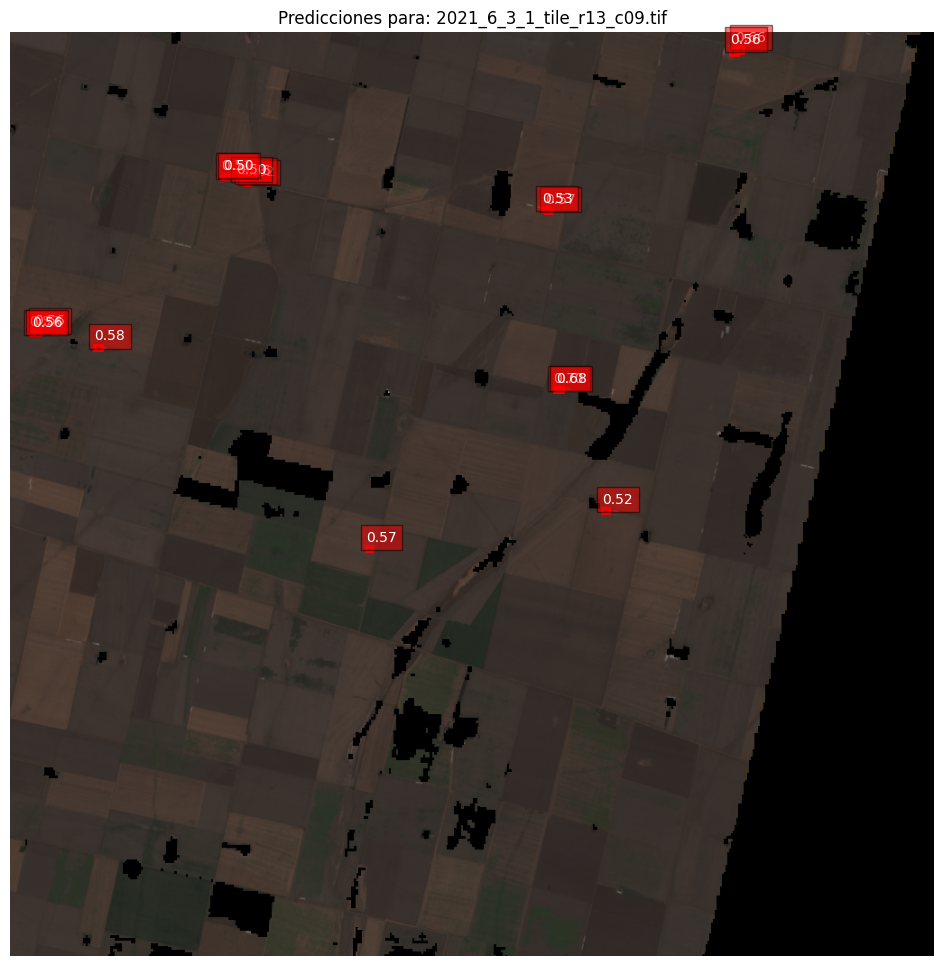

Analizando: 2021_7_15_1_tile_r17_c06.tif


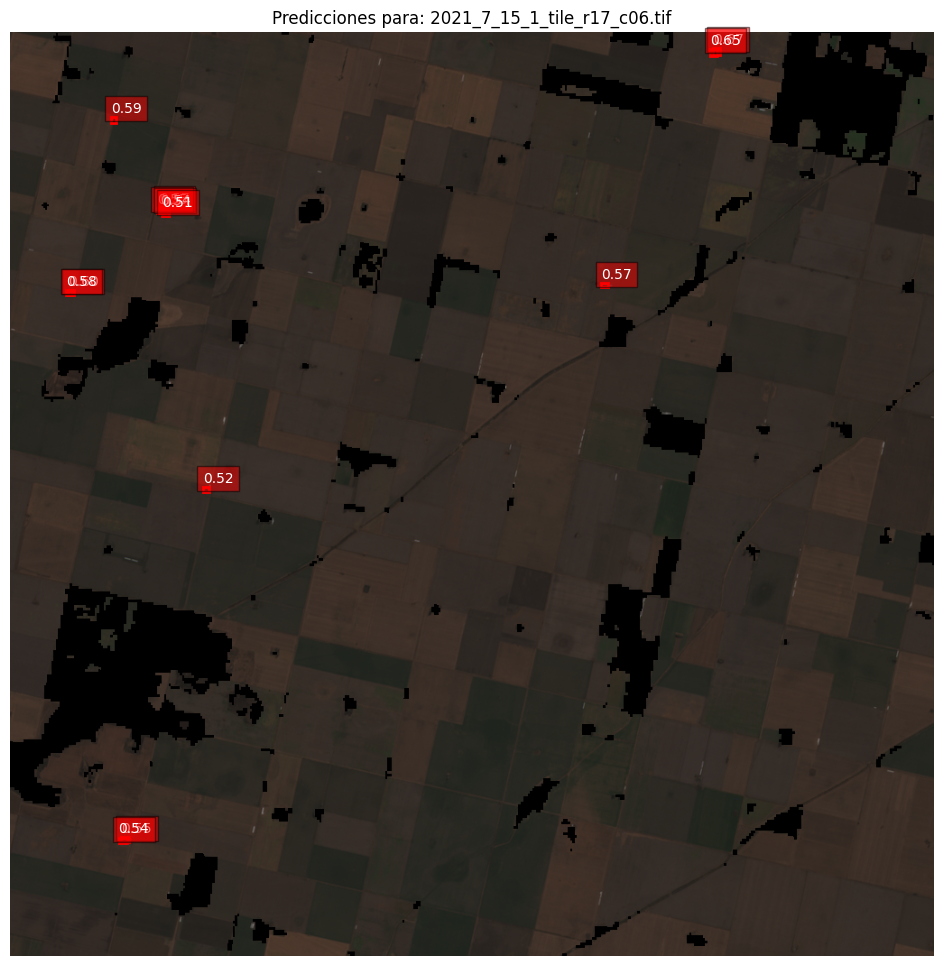

Analizando: 2023_8_2_0_tile_r17_c07.tif
  -> En 2023_8_2_0_tile_r17_c07.tif no se detectaron silos con confianza > 0.5


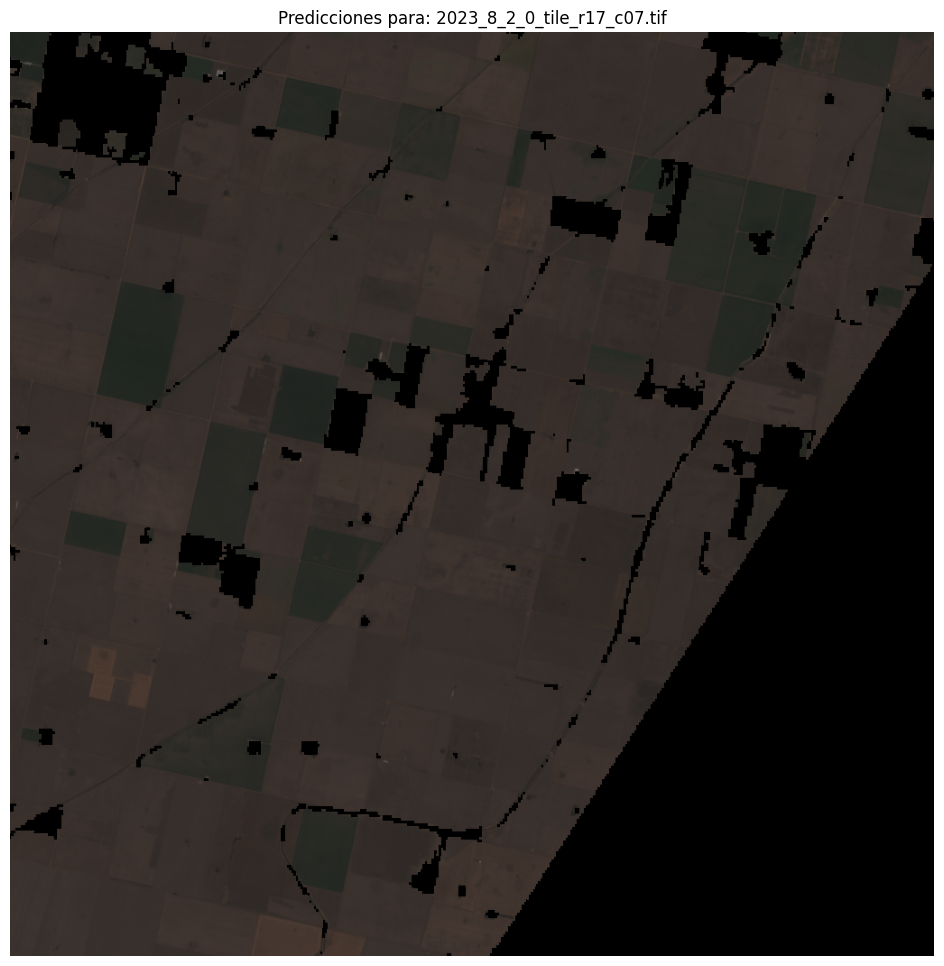

Analizando: 2025_6_19_0_tile_r03_c05.tif
  -> En 2025_6_19_0_tile_r03_c05.tif no se detectaron silos con confianza > 0.5


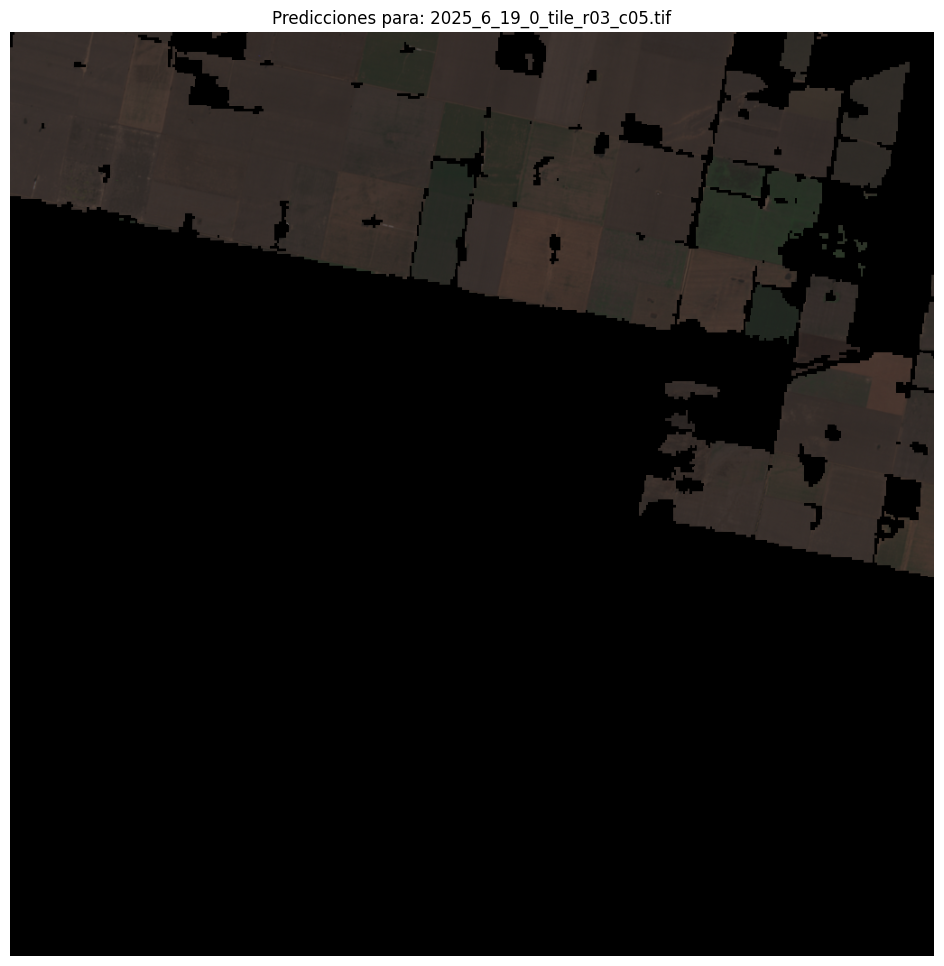

Analizando: 2020_6_25_1_tile_r02_c06.tif


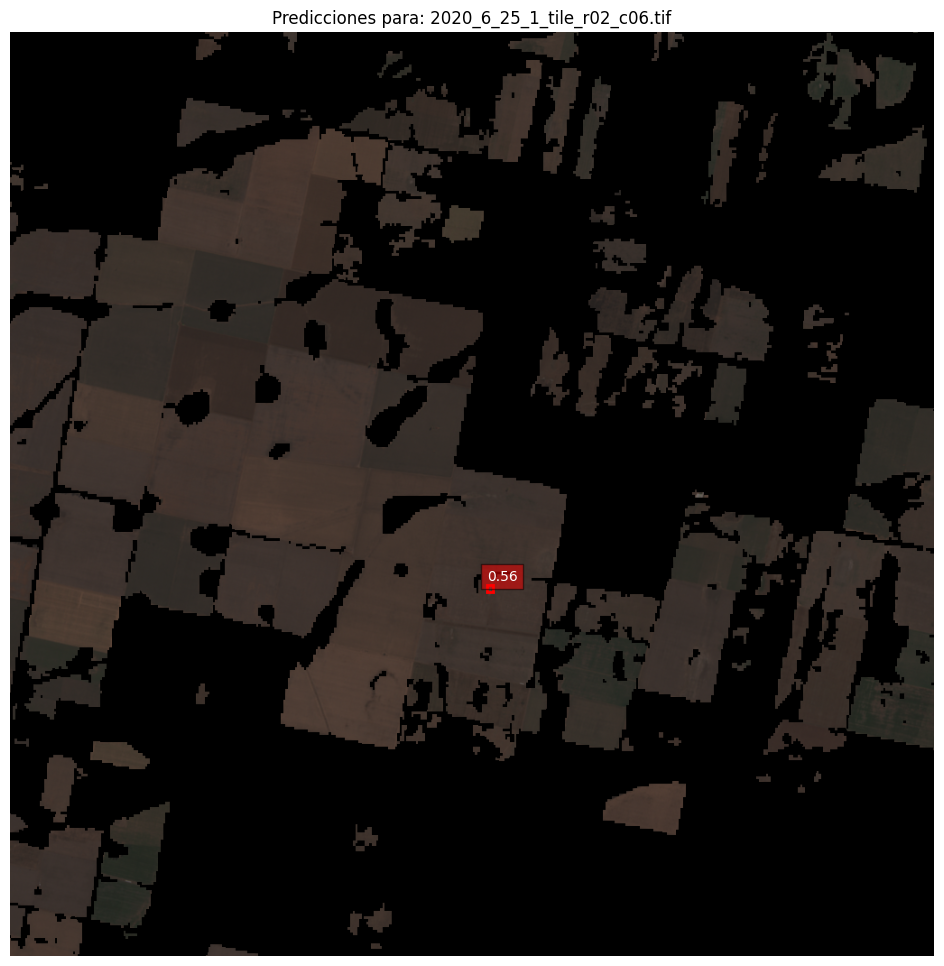

In [1]:
import os
import torch
import torchvision
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import random

# --- 1. CONFIGURACIÓN ---
MODEL_PATH = r"D:\Silos\modelo_silos_v1.pth"      # Donde se guardará tu modelo al terminar
VAL_DIR = r"D:\Silos\Dataset_Entrenamiento_Rapido\val" # Carpeta de validación
THRESHOLD = 0.5  # Confianza mínima para mostrar una caja (50%)

# --- 2. CARGAR EL MODELO (Misma arquitectura que el entrenamiento) ---
def get_model_instance(num_classes):
    # Cargar arquitectura base
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    """Lee y procesa la imagen IGUAL que en el entrenamiento"""
    with rasterio.open(img_path) as src:
        # Leer RGB
        try:
            img_data = src.read([1, 2, 3])
        except:
            img_data = src.read()
            if img_data.shape[0] > 3: img_data = img_data[:3, :, :]
            
    img_data = img_data.astype(np.float32)
    
    # Limpieza de NaNs (CRÍTICO)
    img_data = np.nan_to_num(img_data, nan=0.0, posinf=1.0, neginf=0.0)
    
    # Normalización
    max_val = np.max(img_data)
    if max_val > 255.0:
        img_data = img_data / 10000.0 # Sentinel raw
    elif max_val > 1.0:
        img_data = img_data / 255.0   # uint8
        
    img_data = np.clip(img_data, 0, 1)
    
    # Convertir a Tensor
    img_tensor = torch.as_tensor(img_data, dtype=torch.float32)
    return img_tensor

def plot_prediction(img_tensor, prediction, threshold=0.5, filename=""):
    """Dibuja la imagen y las cajas"""
    # Convertir tensor a numpy para plotear (C, H, W) -> (H, W, C)
    img_numpy = img_tensor.cpu().numpy().transpose(1, 2, 0)
    
    # Crear figura
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(img_numpy)
    ax.set_title(f"Predicciones para: {filename}")
    
    # Obtener cajas y scores
    boxes = prediction[0]['boxes'].cpu().detach().numpy()
    scores = prediction[0]['scores'].cpu().detach().numpy()
    
    found_silo = False
    for box, score in zip(boxes, scores):
        if score >= threshold:
            found_silo = True
            xmin, ymin, xmax, ymax = box
            w = xmax - xmin
            h = ymax - ymin
            
            # Dibujar rectángulo ROJO
            rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            # Poner texto con confianza
            ax.text(xmin, ymin-5, f'{score:.2f}', color='white', fontsize=10, 
                    bbox=dict(facecolor='red', alpha=0.5))
    
    if not found_silo:
        print(f"  -> En {filename} no se detectaron silos con confianza > {threshold}")
        
    plt.axis('off')
    plt.show()

# --- 3. MAIN ---
def main():
    device = torch.device('cpu')
    print(f"Cargando modelo desde {MODEL_PATH}...")
    
    # Verificar si el archivo del modelo existe (por si aún no termina el entrenamiento)
    if not os.path.exists(MODEL_PATH):
        print("¡ESPERA! El archivo del modelo aún no existe.")
        print("Espera a que termine el script de entrenamiento.")
        return

    # Instanciar y cargar pesos
    model = get_model_instance(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval() # Modo evaluación (congela capas)
    
    print("Modelo cargado. Buscando imágenes de prueba...")
    
    # Obtener imágenes de validación
    val_images = [f for f in os.listdir(VAL_DIR) if f.endswith('.tif')]
    
    if not val_images:
        print("No hay imágenes en la carpeta de validación.")
        return

    # Elegir 3 al azar para probar
    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Procesando {len(samples)} imágenes...")
    
    for img_name in samples:
        img_path = os.path.join(VAL_DIR, img_name)
        print(f"Analizando: {img_name}")
        
        # Preprocesar
        img_tensor = preprocess_image(img_path)
        
        # Inferencia
        with torch.no_grad():
            # El modelo espera una lista de tensores [img1, img2...]
            prediction = model([img_tensor.to(device)])
            
        # Visualizar
        plot_prediction(img_tensor, prediction, THRESHOLD, img_name)

if __name__ == "__main__":
    main()

In [ ]:
import os
import torch
import rasterio
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
import random

# --- CONFIGURACIÓN ---
MODEL_PATH = r"D:\Silos\modelo_silos_v2_optimizado.pth"
VAL_DIR = r"D:\Silos\Dataset_V2\val"
OUTPUT_DIR = r"D:\Silos\predicciones_individuales"
THRESHOLD = 0.5
SEED = 42  # <--- DEBE SER EL MISMO QUE EN EL SCRIPT VISUAL

# --- FIJAR SEMILLA ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_model_v2_inference(num_classes):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try: img_data = src.read([1, 2, 3])
        except: img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0: img_data /= 10000.0
    elif max_val > 1.0: img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)

def main_export_seed():
    device = torch.device('cpu')
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    print(f"Generando Shapes para la semilla {SEED}...")
    
    if not os.path.exists(MODEL_PATH): return

    model = get_model_v2_inference(num_classes=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    
    # 1. LISTAR Y ORDENAR (CRÍTICO)
    val_images = sorted([f for f in os.listdir(VAL_DIR) if f.endswith('.tif')])
    if not val_images: return

    # 2. SELECCIONAR LA MISMA MUESTRA
    samples = random.sample(val_images, min(5, len(val_images)))
    
    print(f"Procesando las mismas {len(samples)} imágenes para QGIS:")

    for img_name in samples:
        print(f"--> Exportando: {img_name}")
        img_path = os.path.join(VAL_DIR, img_name)
        
        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])
        
        boxes_px = prediction[0]['boxes'].cpu().numpy()
        scores = prediction[0]['scores'].cpu().numpy()
        
        geometries = []
        valid_scores = []
        
        with rasterio.open(img_path) as src:
            transform = src.transform
            crs = src.crs
            for box_px, score in zip(boxes_px, scores):
                if score >= THRESHOLD:
                    xmin, ymin, xmax, ymax = box_px
                    x_min, y_max = rasterio.transform.xy(transform, ymin, xmin, offset='ul')
                    x_max, y_min = rasterio.transform.xy(transform, ymax, xmax, offset='ul')
                    geo_box = box(x_min, y_min, x_max, y_max)
                    geometries.append(geo_box)
                    valid_scores.append(float(score))
        
        if len(geometries) > 0:
            output_name = f"pred_{os.path.splitext(img_name)[0]}.shp"
            output_path = os.path.join(OUTPUT_DIR, output_name)
            gdf = gpd.GeoDataFrame({'filename': img_name, 'score': valid_scores}, geometry=geometries, crs=crs)
            gdf.to_file(output_path)
        else:
            print(f"   [Info] Sin detecciones > {THRESHOLD}")

    print(f"\n¡Listo! Revisa la carpeta {OUTPUT_DIR}")

if __name__ == "__main__":
    main_export_seed()